# ESM2 full fine tuning


In [1]:
# Dependancies and libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim

from transformers import AutoModel, AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification, DataCollatorWithPadding
from peft import LoraModel, LoraConfig, inject_adapter_in_model
import datasets

import esm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, matthews_corrcoef, roc_auc_score, confusion_matrix

from pathlib import Path

In [2]:
# ESM checkpoints
ESM = ['facebook/esm2_t48_15B_UR50D',
        'facebook/esm2_t36_3B_UR50D',
        'facebook/esm2_t33_650M_UR50D',
        'facebook/esm2_t30_150M_UR50D',
        'facebook/esm2_t12_35M_UR50D',
        'facebook/esm2_t6_8M_UR50D']

In [3]:
# Define checkpoint to be used
checkpoint = ESM[5]

In [12]:
# Select no_fine_tuning = True if generating embeddings from the model with pre-trained weights
no_fine_tuning = False

# Select full fine tuning, change to False if using LoRA
full_fine_tuning = True

if no_fine_tuning:
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModel.from_pretrained(checkpoint)

num_labels = 2

#load ESM2 models
def load_esm_model_classification(checkpoint, num_labels, full):  
    
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    
    model = AutoModelForTokenClassification.from_pretrained(checkpoint, num_labels=num_labels)
    
    if full == True:
        return model, tokenizer 
    
    else:
        peft_config = LoraConfig(
            r=4, lora_alpha=1, bias="all", target_modules=["query","key","value","dense"]
        )
        
        model = inject_adapter_in_model(peft_config, model)
        
        # Unfreeze the prediction head for LoRA (not required for full fine-tuning as head automatically unfrozen)
        for (param_name, param) in model.classifier.named_parameters():
                    param.requires_grad = True  
        
        return model, tokenizer

if no_fine_tuning == False:
    model, tokenizer = load_esm_model_classification(checkpoint, num_labels, full_fine_tuning)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmForTokenClassification LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
classifier.bias           | MISSING    | 
classifier.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
# Select pathogen folder - UPDATE to pathogen of choice
pathogen_dir = Path('/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/Orthopoxvirus')

# Define higher, lower and test data
def select_datasets(pathogen_dir):
    lower_level = None
    higher_level = None
    target = None

    for file in pathogen_dir.iterdir():
        if 'Lower' in file.name:
            lower_level = file
        elif 'Higher' in file.name:
            higher_level = file
        elif 'Target' in file.name:
            target = file

    return lower_level, higher_level, target

# Assign to variables for automatic csv selection in code
lower_level, higher_level, target = select_datasets(pathogen_dir)

### Sliding window 

- Check whether a sequence is greater than 1024 residues in length
- If > 1024, create copy of sequence
- Create segments

In [21]:
def sliding_window(df, window_size=1024, stride=512):
    """
    Function to create 1024 length splits for proteins >1024 in length, using stride length of 512
    Inserts new splits into a datatable with split suffix
    """
    rows = []
    
    for _, row in df.iterrows():
        seq = row['sequence']
        seq_len = len(seq)
        
        if seq_len <= window_size:
            rows.append(row.copy())
            continue
            
        start = 0
        split = 1
        while start < seq_len:
            # End slicing variable
            end = start + window_size

            # Create copy of the row
            new_row = row.copy()
            # Slice amino acid sequence by start end index
            new_row['sequence'] = seq[start:end]
            
            # Slice columns containing lists
            for col in ['label', 'position']:
                new_row[col] = row[col][start:end]

            # Add split suffix to Info_protein_id
            new_row['Info_protein_id'] = str(new_row['Info_protein_id']) + '_' + str(split) 
            # Append window to row list 
            rows.append(new_row)
            
            # Stop after the final window
            if end >= seq_len:
                break
                
            start += stride
            split += 1
            
    return pd.DataFrame(rows).reset_index(drop=True)

In [15]:
# Function to delete rows with all unlabelled residues
def delete_unlabelled_rows(df):
    return df[df['label'].apply(lambda labels: 0 in labels or 1 in labels)].reset_index(drop=True)

### Baseline embedder

In [16]:
def preprocess_for_baseline_embedder(lower_level):# Preprocess training data
    df_lower_stacked = pd.read_csv(lower_level)
    
    # Mask n/a values with -100 
    df_lower_stacked['Class'] = df_lower_stacked['Class'].fillna(-100).astype('int32')
    df_lower_stacked['Class'] = df_lower_stacked['Class'].replace(-1, 0)
    
    # Sort values before aggregation
    df_lower = df_lower_stacked.sort_values(['Info_protein_id', 'Info_pos'])
    
    # Aggregate columns for wide format
    df_lower = df_lower.groupby(['Info_protein_id','Info_group', 'Info_split'], as_index=False).agg(
        sequence=('Info_AA', ''.join), 
        label=('Class', list), 
        position=('Info_pos', list))
    
    # Apply sliding window
    df_lower = sliding_window(df_lower)
    
    # Delete unlabelled rows
    df_lower = delete_unlabelled_rows(df_lower)
    
    # Create train / validation splits using the info split column
    cv_1_train = df_lower[df_lower['Info_split'] != 'split_01_20'].reset_index()
    cv_1_val = df_lower[df_lower['Info_split'] == 'split_01_20'].reset_index()
    
    cv_2_train = df_lower[df_lower['Info_split'] != 'split_02_20'].reset_index()
    cv_2_val = df_lower[df_lower['Info_split'] == 'split_02_20'].reset_index()
    
    cv_3_train = df_lower[df_lower['Info_split'] != 'split_03_20'].reset_index()
    cv_3_val = df_lower[df_lower['Info_split'] == 'split_03_20'].reset_index()
    
    cv_4_train = df_lower[df_lower['Info_split'] != 'split_04_20'].reset_index()
    cv_4_val = df_lower[df_lower['Info_split'] == 'split_04_20'].reset_index()
    
    cv_5_train = df_lower[df_lower['Info_split'] != 'split_05_20'].reset_index()
    cv_5_val = df_lower[df_lower['Info_split'] == 'split_05_20'].reset_index()

    return cv_1_train, cv_1_val, cv_2_train, cv_2_train, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val

In [17]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.to(device)    
    
# Create custom dataset class - add to separate file and import
class SequenceDataset(torch.utils.data.Dataset):
    
    def __init__(self, df):
        self.protein_id = df['Info_protein_id']
        self.sequence = df['sequence']
        self.position = df['position']
        self.labels = df['label']
        
    def __len__(self):
        return len(self.sequence)
        
    def __getitem__(self, idx):
        return {
            'protein_id': self.protein_id.iloc[idx],
            'sequence': self.sequence.iloc[idx],
            'position': self.position.iloc[idx],
            'label': self.labels.iloc[idx]
        }

def collate_fn(batch):
    """
    Function to create a custom collator to maintain length of items within the batch
    """
    return {
        'protein_id': [x['protein_id'] for x in batch],
        'sequence': [x['sequence'] for x in batch],
        'position': [x['position'] for x in batch],
        'label': [x['label'] for x in batch]
    }

def batch_create(dataset, tokenizer, model): 
    """
    Function to create a DataLoader instance using the the custom collate function
    """

    # Create a DataLoader instance using the cv dataset and the custom collate function
    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False,
        collate_fn=collate_fn
    )
    
    emb_output_list = []
    
    # Loop through each batch of tensors and apply tokenisation to each sequence
    for batch in loader:
        
        inputs = tokenizer(
            batch['sequence'],
            padding=True,
            truncation=False,
            return_tensors='pt'
        )
        
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Freeze model weights and calculate embeddings 
        with torch.no_grad():
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state[:, 1:-1, :].cpu() # Slice embeddings to remove start and end CLS/EOS tokens   
        
        # Convert labels to tensors 
        labels = [torch.tensor(x) for x in batch['label']]

        # Pad each label to the size of the largest embedding within the batch
        labels = pad_sequence(labels, batch_first=True, padding_value=-100)

        # Append the embeddings, label and masks per batch to an output list 
        emb_output_list.append({
            'embeddings': embeddings,
            'labels': labels
        })

    return emb_output_list

In [18]:
# Create datasets
def baseline_embedder_create_datasets(cv_1_train, cv_1_val, cv_2_train, cv_2_val, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val):
    train_datasets = {
        1:SequenceDataset(cv_1_train),
        2:SequenceDataset(cv_2_train), 
        3:SequenceDataset(cv_3_train),
        4:SequenceDataset(cv_4_train),
        5:SequenceDataset(cv_5_train)    
    }
    
    val_datasets = {
        1:SequenceDataset(cv_1_val),
        2:SequenceDataset(cv_2_val), 
        3:SequenceDataset(cv_3_val),
        4:SequenceDataset(cv_4_val),
        5:SequenceDataset(cv_5_val)    
    }
    
    # Create train batches
    train_loaded = {}
    
    for key, value in train_datasets.items():
        batched = batch_create(value, tokenizer, model)
        train_loaded[key] = batched
    
    # Create val batches
    val_loaded = {}
    
    for key, value in val_datasets.items():
        batched = batch_create(value, tokenizer, model) 
        val_loaded[key] = batched

    return train_loaded, val_loaded

if no_fine_tuning == True:
    cv_1_train, cv_1_val, cv_2_train, cv_2_val, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val = preprocess_for_baseline_embedder(lower_level)
    train_loaded, val_loaded = baseline_embedder_create_datasets(cv_1_train, cv_1_val, cv_2_train, cv_2_val, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val)


### Fine Tuning

- Fine tune using higher level data

In [25]:
def preprocess_csv_fine_tune(csv_file):
    preprocessed_df = pd.read_csv(csv_file)

    # Mask n/a values with -100 
    preprocessed_df['Class'] = preprocessed_df['Class'].fillna(-100).astype('int32')
    preprocessed_df['Class'] = preprocessed_df['Class'].replace(-1, 0)
    
    # Sort values before aggregation
    preprocessed_df = preprocessed_df.sort_values(['Info_protein_id', 'Info_pos'])
    
    # Aggregate columns for wide format
    preprocessed_df = preprocessed_df.groupby(['Info_protein_id','Info_group', 'Info_split'], as_index=False).agg(  # ,'Info_group', , 'Info_split'
        sequence=('Info_AA', ''.join), 
        label=('Class', list), 
        position=('Info_pos', list))

    # Apply sliding window
    preprocessed_df = sliding_window(preprocessed_df)

    return preprocessed_df

In [26]:
def preprocess_fine_tuning(data):
    """
    Preprocess each df row to tokenise the sequences and pad labels to match max length
    """
    inputs = tokenizer(
            data['sequence'],
            padding='max_length',
            truncation=True, 
            max_length=1026,
        )
    
    labels = data['label']

    # Remove first and last special tokens for tokens and attention mask
    input_ids = inputs['input_ids'][1:-1]
    attn_mask = inputs['attention_mask'][1:-1]

    # Pad labels to max length
    labels = labels + ([-100] * (1024 - len(labels)))

    return {'input_ids': input_ids,
            'attention_mask': attn_mask,
            'labels': labels}

if no_fine_tuning = False:
    df_higher = preprocess_csv_fine_tune(higher_level)
    df_higher = delete_unlabelled_rows(df_higher)

    fine_tune_train_splits = []
    fine_tune_val_splits = []
    
    # Create train / validation splits using the info split column
    fine_tune_1_train = df_higher[df_higher['Info_split'] != 'split_01_20'].reset_index(drop=True)
    fine_tune_1_val = df_higher[df_higher['Info_split'] == 'split_01_20'].reset_index(drop=True)
    fine_tune_2_train = df_higher[df_higher['Info_split'] != 'split_02_20'].reset_index(drop=True)
    fine_tune_2_val = df_higher[df_higher['Info_split'] == 'split_02_20'].reset_index(drop=True)
    fine_tune_3_train = df_higher[df_higher['Info_split'] != 'split_03_20'].reset_index(drop=True)
    fine_tune_3_val = df_higher[df_higher['Info_split'] == 'split_03_20'].reset_index(drop=True)
    fine_tune_4_train = df_higher[df_higher['Info_split'] != 'split_04_20'].reset_index(drop=True)
    fine_tune_4_val = df_higher[df_higher['Info_split'] == 'split_04_20'].reset_index(drop=True)
    fine_tune_5_train = df_higher[df_higher['Info_split'] != 'split_05_20'].reset_index(drop=True)
    fine_tune_5_val = df_higher[df_higher['Info_split'] == 'split_05_20'].reset_index(drop=True)

    fine_tune_train_splits.append(fine_tune_1_train, fine_tune_2_train, fine_tune_3_train, fine_tune_4_train, fine_tune_5_train)
    fine_tune_val_splits.append(fine_tune_1_val, fine_tune_2_val, fine_tune_3_val, fine_tune_4_val, fine_tune_5_val)
    
    
    fine_tune_train_splits = []
    fine_tune_val_splits = []    
    
    # Update pandas dataframes to Hugging face datasets
    for train_split in fine_tune_train_splits:
        dataset = datasets.Dataset.from_pandas(train_split)
        preprocessed_train = train_dataset.map(dataset)
        fine_tune_train_splits.append(preprocessed_train)
        
    for train_split in fine_tune_train_splits:
        dataset = datasets.Dataset.from_pandas(train_split)
        preprocessed_train = train_dataset.map(dataset)
        fine_tune_train_splits.append(preprocessed_train)
    
    val_dataset = datasets.Dataset.from_pandas(cv_1_val)
    
    # Apply preprocess function to datasets
    preprocessed_train = train_dataset.map(preprocess_fine_tuning)
    preprocessed_val = val_dataset.map(preprocess_fine_tuning)
    
    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)


/var/folders/lw/x11_w_4d5f181vzwkqrqhxcm0000gn/T/ipykernel_20679/3720892648.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preprocessed_df = pd.read_csv(csv_file)


TypeError: list.append() takes exactly one argument (5 given)

In [44]:
# Define Trainer parameters
def compute_metrics(p):
    
    # Separate logits and labels
    pred, labels = p    
    
    # Return index of higher position (neg or positive residue) per row
    max_pred = np.argmax(pred, axis=-1)

    # Calculate probabilites to be used for AUC
    probs = torch.softmax(torch.tensor(pred), dim=-1)
    probs = probs[:, :, 1]

    # Create mask for unlabelled positions
    mask = labels != -100

    # Calculate metrics
    accuracy = accuracy_score(y_true=labels[mask], y_pred=max_pred[mask])
    recall = recall_score(y_true=labels[mask], y_pred=max_pred[mask])
    precision = precision_score(y_true=labels[mask], y_pred=max_pred[mask])
    f1 = f1_score(y_true=labels[mask], y_pred=max_pred[mask])
    mcc = matthews_corrcoef(y_true=labels[mask], y_pred=max_pred[mask])
    auc = roc_auc_score(y_true=labels[mask], y_score=probs[mask])

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'mcc': mcc, 'auc': auc}

num_fine_tune_epochs = 3 # 10 in Nature peft paper

training_args = TrainingArguments(
    output_dir='/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/fine-tuned-8M',
    # learning_rate=2e-5,
    per_device_train_batch_size=4, # Match to Nature peft paper
    gradient_accumulation_steps=2, # Match to Nature peft paper
    # per_device_train_batch_size=16,
    per_device_eval_batch_size=4,
    # fp16=False, # Change precision to match Nature paper
    num_train_epochs=num_fine_tune_epochs,
    learning_rate=3e-4, # Match to Nature peft paper
    seed=42, # Match to Nature peft paper
    eval_strategy='epoch', # Update from epoch
    # eval_steps=500, 
    save_strategy='epoch',
    # save_steps=500,
    logging_strategy='epoch', # Steps?
    load_best_model_at_end=True,
    metric_for_best_model='auc',
    greater_is_better=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=preprocessed_train,
    eval_dataset=preprocessed_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# Obtain best model weights
model = trainer.model

# Explicitly save best performing model
# trainer.save_model('/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/fine-tuned-8M/best-performing-model')


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Mcc,Auc
1,0.533232,0.672670,0.675949,0.611607,0.769663,0.681592,0.370288,0.697276
2,0.473334,0.792192,0.593671,0.532957,0.794944,0.638106,0.236908,0.646773
3,0.429877,0.847258,0.565823,0.511344,0.823034,0.630786,0.198277,0.652190


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Train classification head on embeddings from the fine-tuned model

- Inputs: lower level data

In [45]:
# Load full fine tuned model (to save on completing full fine-tuning)
# model = AutoModelForTokenClassification.from_pretrained('/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/fine-tuned-8M/best-performing-model')
model.eval()

EsmForTokenClassification(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 320, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (rotary_embeddings): EsmRotaryEmbedding()
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-5): 6 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=320, out_features=320, bias=True)
              (key): Linear(in_features=320, out_features=320, bias=True)
              (value): Linear(in_features=320, out_features=320, bias=True)
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (dense): Linear(in_features=320, out_

In [49]:
# Preprocess training data
df_lower_stacked = pd.read_csv(lower_level)

# Mask n/a values with -100 
df_lower_stacked['Class'] = df_lower_stacked['Class'].fillna(-100).astype('int32')
df_lower_stacked['Class'] = df_lower_stacked['Class'].replace(-1, 0)

# Sort values before aggregation
df_lower = df_lower_stacked.sort_values(['Info_protein_id', 'Info_pos'])

# Aggregate columns for wide format
df_lower = df_lower.groupby(['Info_protein_id','Info_group', 'Info_split'], as_index=False).agg(
    sequence=('Info_AA', ''.join), 
    label=('Class', list), 
    position=('Info_pos', list))

# Apply sliding window
df_lower = sliding_window(df_lower)

# Delete unlabelled rows
df_lower = delete_unlabelled_rows(df_lower)

# Create train / validation splits using the info split column
cv_1_train = df_lower[df_lower['Info_split'] != 'split_01_20'].reset_index()
cv_1_val = df_lower[df_lower['Info_split'] == 'split_01_20'].reset_index()

cv_2_train = df_lower[df_lower['Info_split'] != 'split_02_20'].reset_index()
cv_2_val = df_lower[df_lower['Info_split'] == 'split_02_20'].reset_index()

cv_3_train = df_lower[df_lower['Info_split'] != 'split_03_20'].reset_index()
cv_3_val = df_lower[df_lower['Info_split'] == 'split_03_20'].reset_index()

cv_4_train = df_lower[df_lower['Info_split'] != 'split_04_20'].reset_index()
cv_4_val = df_lower[df_lower['Info_split'] == 'split_04_20'].reset_index()

cv_5_train = df_lower[df_lower['Info_split'] != 'split_05_20'].reset_index()
cv_5_val = df_lower[df_lower['Info_split'] == 'split_05_20'].reset_index()

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.to(device)
model.eval()

EsmForTokenClassification(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 320, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (rotary_embeddings): EsmRotaryEmbedding()
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-5): 6 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=320, out_features=320, bias=True)
              (key): Linear(in_features=320, out_features=320, bias=True)
              (value): Linear(in_features=320, out_features=320, bias=True)
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (dense): Linear(in_features=320, out_

In [50]:
# Create custom dataset class - add to separate file and import
class SequenceDataset(torch.utils.data.Dataset):
    
    def __init__(self, df):
        self.protein_id = df['Info_protein_id']
        self.sequence = df['sequence']
        self.position = df['position']
        self.labels = df['label']
        
    def __len__(self):
        return len(self.sequence)
        
    def __getitem__(self, idx):
        return {
            'protein_id': self.protein_id.iloc[idx],
            'sequence': self.sequence.iloc[idx],
            'position': self.position.iloc[idx],
            'label': self.labels.iloc[idx]
        }

def collate_fn(batch):
    """
    Function to create a custom collator to maintain length of items within the batch
    """
    return {
        'protein_id': [x['protein_id'] for x in batch],
        'sequence': [x['sequence'] for x in batch],
        'position': [x['position'] for x in batch],
        'label': [x['label'] for x in batch]
    }

def batch_create(dataset, tokenizer, model): 
    """
    Function to create a DataLoader instance using the the custom collate function
    """
    # Create a DataLoader instance using the cv dataset and the custom collate function
    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False,
        collate_fn=collate_fn
    )
    
    emb_output_list = []
    
    # Loop through each batch of tensors and apply tokenisation to each sequence
    for batch in loader:
        
        inputs = tokenizer(
            batch['sequence'],
            padding=True,
            truncation=False,
            return_tensors='pt'
        )
        
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Freeze model weights and calculate embeddings 
        with torch.no_grad():
            outputs = model.esm(**inputs)
            embeddings = outputs.last_hidden_state[:, 1:-1, :].cpu() # Slice embeddings to remove start and end CLS/EOS tokens   
        
        # Convert labels to tensors 
        labels = [torch.tensor(x) for x in batch['label']]

        # Pad each label to the size of the largest embedding within the batch
        labels = pad_sequence(labels, batch_first=True, padding_value=-100)

        # Append the embeddings, label and masks per batch to an output list 
        emb_output_list.append({
            'embeddings': embeddings,
            'labels': labels
        })

    return emb_output_list

In [51]:
# Create datasets
train_datasets = {
    1:SequenceDataset(cv_1_train),
    2:SequenceDataset(cv_2_train), 
    3:SequenceDataset(cv_3_train),
    4:SequenceDataset(cv_4_train),
    5:SequenceDataset(cv_5_train)    
}

val_datasets = {
    1:SequenceDataset(cv_1_val),
    2:SequenceDataset(cv_2_val), 
    3:SequenceDataset(cv_3_val),
    4:SequenceDataset(cv_4_val),
    5:SequenceDataset(cv_5_val)    
}

# Create train batches
train_loaded = {}

for key, value in train_datasets.items():
    batched = batch_create(value, tokenizer, model)
    train_loaded[key] = batched

# Create val batches
val_loaded = {}

for key, value in val_datasets.items():
    batched = batch_create(value, tokenizer, model) 
    val_loaded[key] = batched

In [52]:
# # Classification head
class PerResidueClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(320, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)

In [54]:
# Determine frequency of positive vs negative labels to be used to weight the loss function
neg_class = len(df_lower_stacked[df_lower_stacked['Class'] == 0])
pos_class = len(df_lower_stacked[df_lower_stacked['Class'] == 1])

# Total labelled 
total = neg_class + pos_class

# Set the weight as the inverse proportion of the tota
neg_weight = torch.tensor([total/(2*neg_class)])
pos_weight = torch.tensor([total/(2*pos_class)])

# Concat tensors 
weight = torch.cat([neg_weight, pos_weight])
weight

tensor([1.2183, 0.8481])

In [55]:
# Checkpoint directory
checkpoint_dir = Path("/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/clf_checkpoint")
checkpoint_dir.mkdir(exist_ok=True)

In [56]:
# Model
clf = PerResidueClassifier()

# AdamW optimiser
optimiser = optim.AdamW(clf.parameters(), lr=0.001)

# Instantiate cross-entropy loss function, ignores positions with mask -100
loss_fcn = nn.CrossEntropyLoss(weight=weight, ignore_index=-100) 

def train_one_epoch(model, train_dataloader, optimiser, loss_function):    

    # Put the clf in training mode
    model.train()
    
    running_loss = 0
    
    train_preds = []
    train_labels = []

    
    for batch in train_dataloader:
        inputs = batch['embeddings']
        labels = batch['labels']
        
        # Zero model gradients per batch
        optimiser.zero_grad()
        
        # Caluclate logits by passing embeddings through the classifier
        outputs = model(inputs)

        # Compute loss and gradients        
        loss = loss_function(outputs.reshape(-1, 2), labels.reshape(-1))

        # Calculate the gradients through the network
        loss.backward()

        # Adjust learning weights
        optimiser.step()

        # Add the loss to a running counter
        running_loss += loss.item()

        # Predicted labels, assign pos or negative based on argmax of the pos / neg class logits, flatten
        train_preds.append(torch.argmax(outputs, dim=-1).reshape(-1))
        train_labels.append(labels.reshape(-1))

        
    train_preds = torch.cat(train_preds)
    train_labels = torch.cat(train_labels)

    mask = train_labels != -100

    metrics = {
        'loss': running_loss / len(train_dataloader),
        'accuracy': accuracy_score(
            train_labels[mask],
            train_preds[mask],
        ),
    }

    return metrics


def val_one_epoch(model, val_dataloader, loss_function):
    
    # Put the classifier into evaluation mode
    model.eval()

    running_loss = 0

    val_preds = []
    val_labels = []
    val_probs = []
    
    # Training loop 
    with torch.no_grad():
        for batch in val_dataloader:
            inputs = batch['embeddings']
            labels = batch['labels']

            # Caluclate logits by passing embeddings through the classifier
            outputs = model(inputs)
    
            # Compute loss and gradients        
            loss = loss_function(outputs.reshape(-1, 2), labels.reshape(-1))
    
            # Add the loss to a running counter
            running_loss += loss.item()
    
            # Predicted labels, assign pos or negative based on argmax of the pos / neg class logits, flatten and append
            val_preds.append(torch.argmax(outputs, dim=-1).reshape(-1))
            val_labels.append(labels.reshape(-1))
            
            # Calculate probabilites to be used for AUC
            probs = torch.softmax(outputs, dim=-1)
            pos_probs_flat = probs[:, :, 1].reshape(-1)
            val_probs.append(pos_probs_flat)

    # Concat the batched tensors in the lists 
    val_preds = torch.cat(val_preds)
    val_labels = torch.cat(val_labels) 
    val_probs = torch.cat(val_probs)

    mask = val_labels != -100
    
    # Calcualte validation metrics
    metrics = {
    'loss': running_loss / len(val_dataloader),
    'accuracy': accuracy_score(val_labels[mask], val_preds[mask]),
    'precision': precision_score(val_labels[mask], val_preds[mask]),
    'recall': recall_score(val_labels[mask], val_preds[mask]),
    'f1': f1_score(val_labels[mask], val_preds[mask]),
    'mcc': matthews_corrcoef(val_labels[mask], val_preds[mask]),
    'auc': roc_auc_score(val_labels[mask], val_probs[mask])
    }
    
    return metrics


def train_classifier(model,
    train_dataloader,
    val_dataloader,
    optimiser,
    loss_function,
    checkpoint_dir,
    epochs=20):

    logs = []

    for key in train_dataloader.keys():

        model = PerResidueClassifier()
        
        optimiser = torch.optim.AdamW(model.parameters(), lr=0.001)
        
        best_auc = 0

        for epoch in range(epochs):

            train_metrics = train_one_epoch(model, train_dataloader[key], optimiser, loss_function)

            val_metrics = val_one_epoch(model, val_dataloader[key], loss_function)

            logs.append({
                'fold': key,
                'epoch': epoch + 1,
                'train_loss': train_metrics['loss'],
                'train_acc': train_metrics['accuracy'],
                'val_loss': val_metrics['loss'],
                'val_acc': val_metrics['accuracy'],
                'val_precision': val_metrics['precision'],
                'val_recall': val_metrics['recall'],
                'val_f1': val_metrics['f1'],
                'val_mcc': val_metrics['mcc'],
                'val_auc': val_metrics['auc'],
            })
                                             
            if val_metrics['auc'] > best_auc:
                best_auc = val_metrics['auc']

                torch.save(
                    model.state_dict(),
                    checkpoint_dir / f'best_classifier_{key}.pt',
                )

    history = pd.DataFrame(logs)
            
    return history


checkpoint_dir = Path("/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/clf_checkpoint")
checkpoint_dir.mkdir(exist_ok=True)

clf_trained = train_classifier(clf, train_loaded, val_loaded,  optimiser, loss_fcn, checkpoint_dir, epochs=20)

In [57]:
clf_trained_avg_metrics = clf_trained.groupby('epoch')[[
    'train_loss', 
    'train_acc', 
    'val_loss', 
    'val_acc', 
    'val_precision', 
    'val_recall', 
    'val_f1', 
    'val_mcc', 
    'val_auc']].mean()

clf_trained_avg_metrics

,train_loss,train_acc,val_loss,val_acc,val_precision,val_recall,val_f1,val_mcc,val_auc
epoch,,,,,,,,,
1,0.687229,0.552319,0.706493,0.610388,0.610388,1.000000,0.756626,0.000000,0.521653
2,0.687831,0.578280,0.690296,0.610118,0.610397,0.999017,0.756331,0.005145,0.537944
3,0.679310,0.585246,0.687407,0.610143,0.610349,0.999283,0.756385,-0.002063,0.540850
4,0.677042,0.579255,0.688093,0.608808,0.610043,0.996170,0.755210,-0.008088,0.546342
5,0.672742,0.582385,0.689326,0.608606,0.610412,0.993324,0.754614,0.002860,0.548721
6,0.668449,0.581874,0.690886,0.607154,0.610211,0.988703,0.753077,0.004000,0.555430
7,0.663865,0.585103,0.691981,0.606121,0.609975,0.985543,0.751977,0.002137,0.556601
8,0.658862,0.588338,0.691696,0.605856,0.610573,0.979464,0.750673,0.008372,0.560805
9,0.654272,0.591366,0.691375,0.605231,0.611882,0.970116,0.748688,0.021545,0.563028


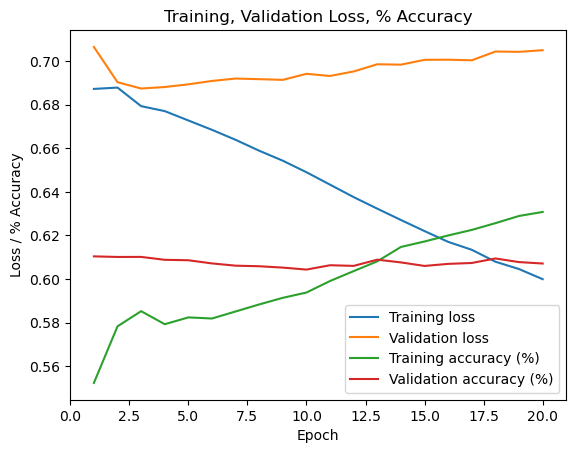

In [58]:
# Plot mean loss per epoch 
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['train_loss'], label='Training loss')
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['val_loss'], label='Validation loss')
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['train_acc'], label='Training accuracy (%)')
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['val_acc'], label='Validation accuracy (%)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / % Accuracy')
ax.set_title('Training, Validation Loss, % Accuracy')
ax.set_xlim(0, len(clf_trained_avg_metrics)+1)

ax.legend()
plt.show()

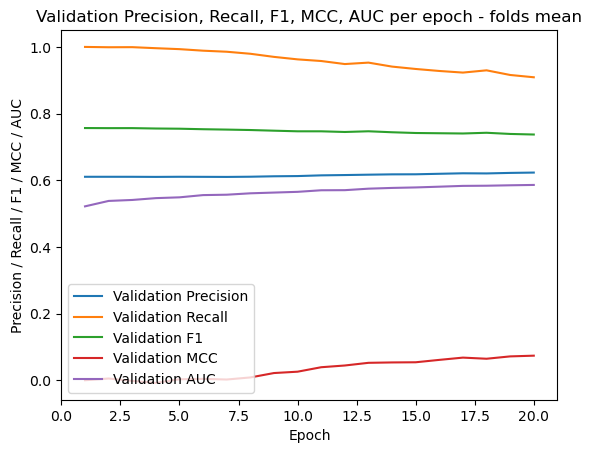

In [59]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['val_precision'], label='Validation Precision')
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['val_recall'], label='Validation Recall')
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['val_f1'], label='Validation F1')
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['val_mcc'], label='Validation MCC')
ax.plot(range(1, len(clf_trained_avg_metrics)+1), clf_trained_avg_metrics['val_auc'], label='Validation AUC')
ax.set_xlabel('Epoch')
ax.set_ylabel('Precision / Recall / F1 / MCC / AUC')
ax.set_title('Validation Precision, Recall, F1, MCC, AUC per epoch - folds mean')
ax.set_xlim(0, len(clf_trained_avg_metrics)+1)

ax.legend()
plt.show()

### Predictions on test data

- Predictions using the fine tuned ESM2 model with integrated token classification head. 

In [60]:
# Preprocess test set and generate embeddings using ESM2 as standard model
# test_df = preprocess_csv('/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/Bunyaviricetes/Target_3151693.csv')

# test_df = datasets.Dataset.from_pandas(test_df)

# Tokenise and preprocess labels
# preprocessed_test = test_df.map(preprocess)

In [61]:
# Run tokens through the fine-tuned model and compute metrics 
# predictions = trainer.predict(preprocessed_test)

In [62]:
# pd.DataFrame(predictions.metrics, index=np.array(np.arange(1,2)))

- Predictions using the fine tuned ESM2 model as embedder, then classify tokens using pre-trained (lower level data) classifier 

In [63]:
# Preprocess training data
test_df_2 = pd.read_csv(target)

# Mask n/a values with -100 
test_df_2['Class'] = test_df_2['Class'].fillna(-100).astype('int32')
test_df_2['Class'] = test_df_2['Class'].replace(-1, 0)

# Sort values before aggregation
test_df_2 = test_df_2.sort_values(['Info_protein_id', 'Info_pos'])

# Aggregate columns for wide format
test_df_2 = test_df_2.groupby(['Info_protein_id'], as_index=False).agg(  #,'Info_group'
    sequence=('Info_AA', ''.join), 
    label=('Class', list), 
    position=('Info_pos', list))

# Apply sliding window
test_df_2 = sliding_window(test_df_2)

# Create datasets
test_datasets = {1:SequenceDataset(test_df_2)}

# Create train batches
test_loaded = {}

for key, value in test_datasets.items():
    batched = batch_create(value, tokenizer, model)
    test_loaded[key] = batched


Evaluate using pretrained classifier

In [64]:
# Put the classifier in eval mode
clf.eval()

test_preds = []
test_labels = []
test_probs = []

for batch in test_loaded[1]:

    with torch.no_grad():
        outputs = clf(batch['embeddings'])

    preds = outputs.argmax(dim=-1).reshape(-1)
    probs = outputs.softmax(dim=-1)[:, :, 1].reshape(-1)
    labels = batch['labels'].reshape(-1)

    test_preds.append(preds)
    test_labels.append(labels)
    test_probs.append(probs)

# Concat tensors
test_preds = torch.cat(test_preds)
test_labels = torch.cat(test_labels)
test_probs = torch.cat(test_probs)

mask = test_labels != -100

test_preds = test_preds[mask]
test_labels = test_labels[mask]
test_probs = test_probs[mask]

# Calculate metrics
accuracy = accuracy_score(test_labels.numpy(), test_preds.numpy())
precision = precision_score(test_labels.numpy(), test_preds.numpy())
recall = recall_score(test_labels.numpy(), test_preds.numpy())
f1 = f1_score(test_labels.numpy(), test_preds.numpy())
mcc = matthews_corrcoef(test_labels.numpy(), test_preds.numpy())
auc = roc_auc_score(test_labels.numpy(), test_probs.numpy())

In [65]:
# Create pandas dataframe
data = { 'Accuracy':accuracy, 'Precision':precision, 'Recall':recall, 'F1':f1, 'mcc':mcc, 'auc':auc}
pd.DataFrame(data, index=np.array(np.arange(1,2)))

,Accuracy,Precision,Recall,F1,mcc,auc
1,0.599115,0.701134,0.737986,0.719088,0.021045,0.507658
